In [3]:
import os

path = "/Users/mouyasushi/Desktop/fifa/worldCup"
print("Path to dataset files:", path)
print("Files inside:", os.listdir(path))


Path to dataset files: /Users/mouyasushi/Desktop/fifa/worldCup
Files inside: ['WorldCupPlayers.csv', '.DS_Store', 'intl', 'WorldCups.csv', 'WorldCupMatches.csv']


In [5]:
# Load the matches CSV into a pandas DataFrame.
import pandas as pd
import numpy as np

initial_df = pd.read_csv(f"{path}/WorldCupMatches.csv")

# This Kaggle file ships with a handful of fully-empty trailing rows — drop them
# so they don't show up as NaNs in every aggregation later on.
initial_df = initial_df.dropna(subset=["Year"]).reset_index(drop=True)

# Year was inferred as float (because of the NaN rows above). Cast to int now
# that the NaNs are gone, so it displays as 1930 rather than 1930.0.
initial_df["Year"] = initial_df["Year"].astype(int)

# Normalize column names to snake_case for cleaner downstream identifiers.
initial_df.columns = [c.lower().replace(" ", "_") for c in initial_df.columns]

initial_df.head()


,year,datetime,stage,stadium,city,home_team_name,home_team_goals,away_team_goals,away_team_name,win_conditions,attendance,half-time_home_goals,half-time_away_goals,referee,assistant_1,assistant_2,roundid,matchid,home_team_initials,away_team_initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [6]:

initial_df.columns.tolist()

['year',
 'datetime',
 'stage',
 'stadium',
 'city',
 'home_team_name',
 'home_team_goals',
 'away_team_goals',
 'away_team_name',
 'win_conditions',
 'attendance',
 'half-time_home_goals',
 'half-time_away_goals',
 'referee',
 'assistant_1',
 'assistant_2',
 'roundid',
 'matchid',
 'home_team_initials',
 'away_team_initials']

In [7]:

cols_to_drop = [
    "win_conditions",
    "attendance",
    "referee",
    "assistant_1",
    "assistant_2",
    "roundid",
    "matchid",
]

initial_df = initial_df.drop(columns=cols_to_drop)

initial_df.head()

,year,datetime,stage,stadium,city,home_team_name,home_team_goals,away_team_goals,away_team_name,half-time_home_goals,half-time_away_goals,home_team_initials,away_team_initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,3.0,0.0,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,2.0,0.0,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,2.0,0.0,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,1.0,0.0,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,0.0,0.0,ARG,FRA


In [8]:
initial_df.head()
initial_df.shape
initial_df.info()
initial_df.isnull().sum()
initial_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  852 non-null    int64  
 1   datetime              852 non-null    str    
 2   stage                 852 non-null    str    
 3   stadium               852 non-null    str    
 4   city                  852 non-null    str    
 5   home_team_name        852 non-null    str    
 6   home_team_goals       852 non-null    float64
 7   away_team_goals       852 non-null    float64
 8   away_team_name        852 non-null    str    
 9   half-time_home_goals  852 non-null    float64
 10  half-time_away_goals  852 non-null    float64
 11  home_team_initials    852 non-null    str    
 12  away_team_initials    852 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 86.7 KB


np.int64(16)

In [9]:
import numpy as np

initial_df.drop(columns=["result"], errors="ignore", inplace=True)

# Recreate result column
initial_df["result"] = np.where(
    initial_df["home_team_goals"] > initial_df["away_team_goals"],
    "Home Win",
    np.where(
        initial_df["home_team_goals"] < initial_df["away_team_goals"],
        "Away Win",
        "Draw"
    )
)

# Recreate helper columns
initial_df["total_goals"] = (
    initial_df["home_team_goals"] +
    initial_df["away_team_goals"]
)

initial_df["goal_difference"] = (
    initial_df["home_team_goals"] -
    initial_df["away_team_goals"]
)

initial_df["home_clean_sheet"] = (
    initial_df["away_team_goals"] == 0
).astype(int)

initial_df["away_clean_sheet"] = (
    initial_df["home_team_goals"] == 0
).astype(int)

initial_df["home_failed_to_score"] = (
    initial_df["home_team_goals"] == 0
).astype(int)

initial_df["away_failed_to_score"] = (
    initial_df["away_team_goals"] == 0
).astype(int)

# Quick check
print(initial_df[[
    "home_team_name",
    "away_team_name",
    "home_team_goals",
    "away_team_goals",
    "result",
    "total_goals",
    "goal_difference"
]].head())

  home_team_name away_team_name  home_team_goals  away_team_goals    result  \
0         France         Mexico              4.0              1.0  Home Win   
1            USA        Belgium              3.0              0.0  Home Win   
2     Yugoslavia         Brazil              2.0              1.0  Home Win   
3        Romania           Peru              3.0              1.0  Home Win   
4      Argentina         France              1.0              0.0  Home Win   

   total_goals  goal_difference  
0          5.0              3.0  
1          3.0              3.0  
2          3.0              1.0  
3          4.0              2.0  
4          1.0              1.0  


In [10]:
eda_cols = [
    "year",
    "datetime",
    "stage",
    "stadium",
    "city",
    "home_team_name",
    "away_team_name",
    "home_team_goals",
    "away_team_goals",
    "half-time_home_goals",
    "half-time_away_goals",
    "home_team_initials",
    "away_team_initials",
    "result",
    "total_goals",
    "goal_difference"
]

direct_model_cols = [
    "year",
    "stage",
    "home_team_name",
    "away_team_name",
    "home_team_initials",
    "away_team_initials"
]

optional_model_cols = [
    "stadium",
    "city",
    "datetime"
]

leakage_cols = [
    "home_team_goals",
    "away_team_goals",
    "half-time_home_goals",
    "half-time_away_goals",
    "total_goals",
    "goal_difference"
]

initial_df["goal_difference"] = (
    initial_df["home_team_goals"] - initial_df["away_team_goals"]
)

initial_df["total_goals"] = (
    initial_df["home_team_goals"] + initial_df["away_team_goals"]
)

initial_df["home_clean_sheet"] = (initial_df["away_team_goals"] == 0).astype(int)
initial_df["away_clean_sheet"] = (initial_df["home_team_goals"] == 0).astype(int)

initial_df["home_failed_to_score"] = (initial_df["home_team_goals"] == 0).astype(int)
initial_df["away_failed_to_score"] = (initial_df["away_team_goals"] == 0).astype(int)

In [11]:
initial_df["home_win"] = (initial_df["result"] == "Home Win").astype(int)
initial_df["away_win"] = (initial_df["result"] == "Away Win").astype(int)
initial_df["draw"] = (initial_df["result"] == "Draw").astype(int)

In [12]:
initial_df["half_time_goal_difference"] = (
    initial_df["half-time_home_goals"] - initial_df["half-time_away_goals"]
)

initial_df["second_half_home_goals"] = (
    initial_df["home_team_goals"] - initial_df["half-time_home_goals"]
)

initial_df["second_half_away_goals"] = (
    initial_df["away_team_goals"] - initial_df["half-time_away_goals"]
)

In [13]:
import numpy as np

initial_df["result"] = np.where(
    initial_df["home_team_goals"] > initial_df["away_team_goals"], "Home Win",
    np.where(initial_df["home_team_goals"] < initial_df["away_team_goals"], "Away Win", "Draw")
)

In [14]:
initial_df["total_goals"] = initial_df["home_team_goals"] + initial_df["away_team_goals"]
initial_df["goal_difference"] = initial_df["home_team_goals"] - initial_df["away_team_goals"]

In [15]:
initial_df["result"].value_counts()
initial_df["stage"].value_counts()
initial_df.groupby("year")["total_goals"].mean()
initial_df.groupby("home_team_name")["home_team_goals"].mean().sort_values(ascending=False)
initial_df.groupby("away_team_name")["away_team_goals"].mean().sort_values(ascending=False)

away_team_name
Czech Republic             3.000000
Germany                    2.500000
Netherlands                1.818182
Brazil                     1.730769
Germany FR                 1.684211
                             ...   
Cuba                       0.000000
Dutch East Indies          0.000000
Zaire                      0.000000
rn">Trinidad and Tobago    0.000000
Iraq                       0.000000
Name: away_team_goals, Length: 83, dtype: float64

In [16]:
initial_df.head()
initial_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       852 non-null    int64  
 1   datetime                   852 non-null    str    
 2   stage                      852 non-null    str    
 3   stadium                    852 non-null    str    
 4   city                       852 non-null    str    
 5   home_team_name             852 non-null    str    
 6   home_team_goals            852 non-null    float64
 7   away_team_goals            852 non-null    float64
 8   away_team_name             852 non-null    str    
 9   half-time_home_goals       852 non-null    float64
 10  half-time_away_goals       852 non-null    float64
 11  home_team_initials         852 non-null    str    
 12  away_team_initials         852 non-null    str    
 13  result                     852 non-null    str    
 14  total

In [17]:
# matplotlib + seaborn are pre-installed on Kaggle.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = "/Users/mouyasushi/Desktop/fifa/worldCup"

# Same load + clean + normalize pipeline as cell 04301d89, but on a separate variable.
eda_df = pd.read_csv(f"{DATA_DIR}/WorldCupMatches.csv").dropna(subset=["Year"]).reset_index(drop=True)
eda_df["Year"] = eda_df["Year"].astype(int)
eda_df.columns = [c.lower().replace(" ", "_") for c in eda_df.columns]
eda_df["total_goals"] = eda_df["home_team_goals"] + eda_df["away_team_goals"]

print(f"Loaded {len(eda_df)} matches across {eda_df['year'].nunique()} World Cups")
eda_df.head()


Loaded 852 matches across 20 World Cups


,year,datetime,stage,stadium,city,home_team_name,home_team_goals,away_team_goals,away_team_name,win_conditions,...,half-time_home_goals,half-time_away_goals,referee,assistant_1,assistant_2,roundid,matchid,home_team_initials,away_team_initials,total_goals
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,5.0
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,3.0
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,...,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA,3.0
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,...,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER,4.0
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,...,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA,1.0


In [18]:

print("Shape:", eda_df.shape)
print("\nMissing values per column:")
print(eda_df.isna().sum())
print("\nNumeric summary:")
eda_df[["home_team_goals", "away_team_goals", "attendance", "total_goals"]].describe()

Shape: (852, 21)

Missing values per column:
year                    0
datetime                0
stage                   0
stadium                 0
city                    0
home_team_name          0
home_team_goals         0
away_team_goals         0
away_team_name          0
win_conditions          0
attendance              2
half-time_home_goals    0
half-time_away_goals    0
referee                 0
assistant_1             0
assistant_2             0
roundid                 0
matchid                 0
home_team_initials      0
away_team_initials      0
total_goals             0
dtype: int64

Numeric summary:


,home_team_goals,away_team_goals,attendance,total_goals
count,852.000000,852.000000,850.000000,852.000000
mean,1.811033,1.022300,45164.800000,2.833333
std,1.610255,1.087573,23485.249247,1.954336
min,0.000000,0.000000,2000.000000,0.000000
25%,1.000000,0.000000,30000.000000,1.000000
50%,2.000000,1.000000,41579.500000,3.000000
75%,3.000000,2.000000,61374.500000,4.000000
max,10.000000,7.000000,173850.000000,12.000000


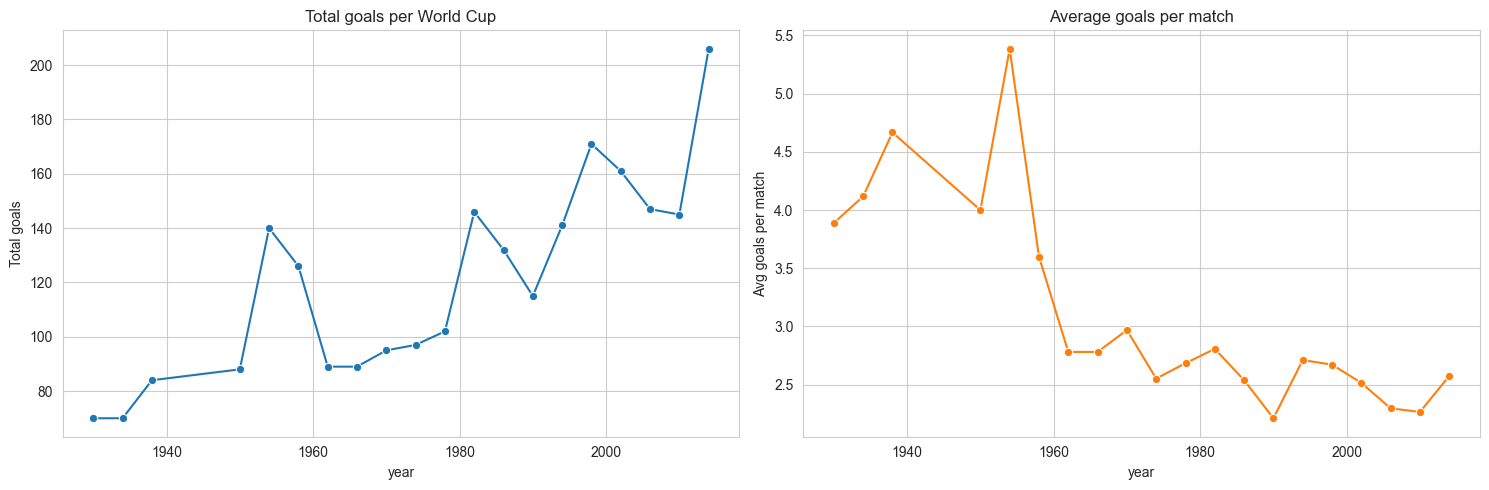

,year,total_goals,avg_goals,n_matches
0,1930,70.0,3.888889,18
1,1934,70.0,4.117647,17
2,1938,84.0,4.666667,18
3,1950,88.0,4.000000,22
4,1954,140.0,5.384615,26
5,1958,126.0,3.600000,35
6,1962,89.0,2.781250,32
7,1966,89.0,2.781250,32
8,1970,95.0,2.968750,32
9,1974,97.0,2.552632,38


In [19]:
# === 3. Goals over time: are matches getting more or less goal-heavy? ===
# Aggregates per tournament year — total goals across all matches and the per-match average.
goals_per_year = eda_df.groupby("year").agg(
    total_goals=("total_goals", "sum"),
    avg_goals=("total_goals", "mean"),
    n_matches=("total_goals", "count"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=goals_per_year, x="year", y="total_goals", marker="o", ax=axes[0])
axes[0].set_title("Total goals per World Cup")
axes[0].set_ylabel("Total goals")

sns.lineplot(data=goals_per_year, x="year", y="avg_goals", marker="o", color="tab:orange", ax=axes[1])
axes[1].set_title("Average goals per match")
axes[1].set_ylabel("Avg goals per match")
plt.tight_layout()
plt.show()

goals_per_year

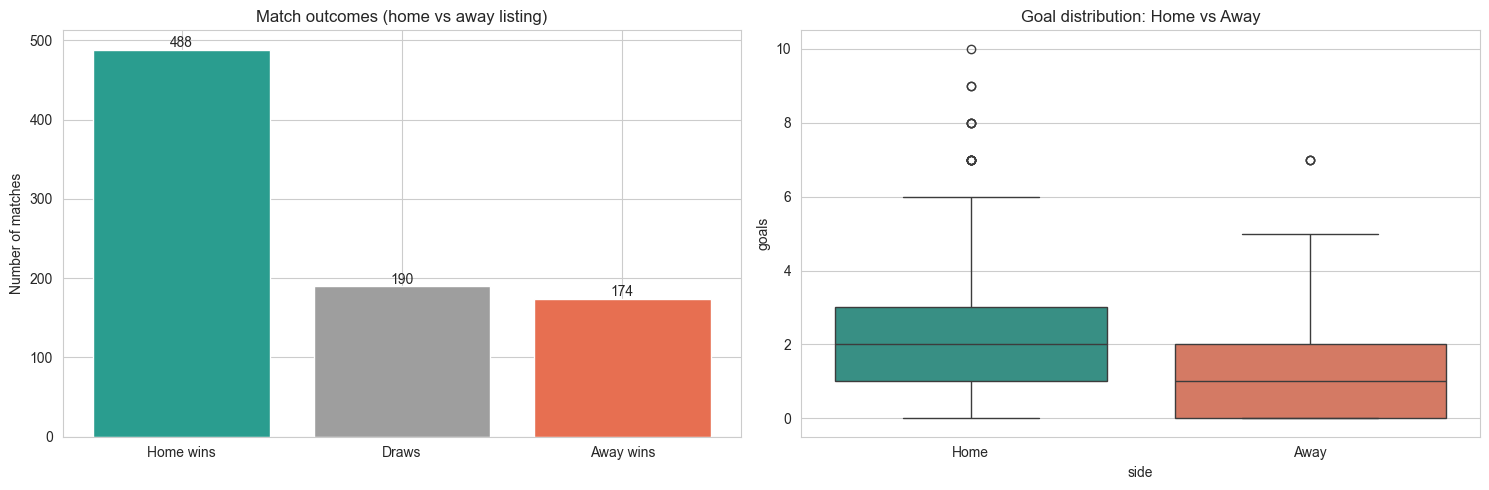

Home win rate: 57.3%
Draw rate:     22.3%
Away win rate: 20.4%


In [20]:

home_wins = int((eda_df["home_team_goals"] > eda_df["away_team_goals"]).sum())
away_wins = int((eda_df["home_team_goals"] < eda_df["away_team_goals"]).sum())
draws    = int((eda_df["home_team_goals"] == eda_df["away_team_goals"]).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(["Home wins", "Draws", "Away wins"], [home_wins, draws, away_wins],
            color=["#2a9d8f", "#9e9e9e", "#e76f51"])
axes[0].set_title("Match outcomes (home vs away listing)")
axes[0].set_ylabel("Number of matches")
for i, v in enumerate([home_wins, draws, away_wins]):
    axes[0].text(i, v + 3, str(v), ha="center")

goals_long = pd.DataFrame({
    "goals": pd.concat([eda_df["home_team_goals"], eda_df["away_team_goals"]], ignore_index=True),
    "side": ["Home"] * len(eda_df) + ["Away"] * len(eda_df),
})
sns.boxplot(data=goals_long, x="side", y="goals", ax=axes[1],
            hue="side", palette=["#2a9d8f", "#e76f51"], legend=False)
axes[1].set_title("Goal distribution: Home vs Away")
plt.tight_layout()
plt.show()

n = len(eda_df)
print(f"Home win rate: {home_wins / n:.1%}")
print(f"Draw rate:     {draws / n:.1%}")
print(f"Away win rate: {away_wins / n:.1%}")

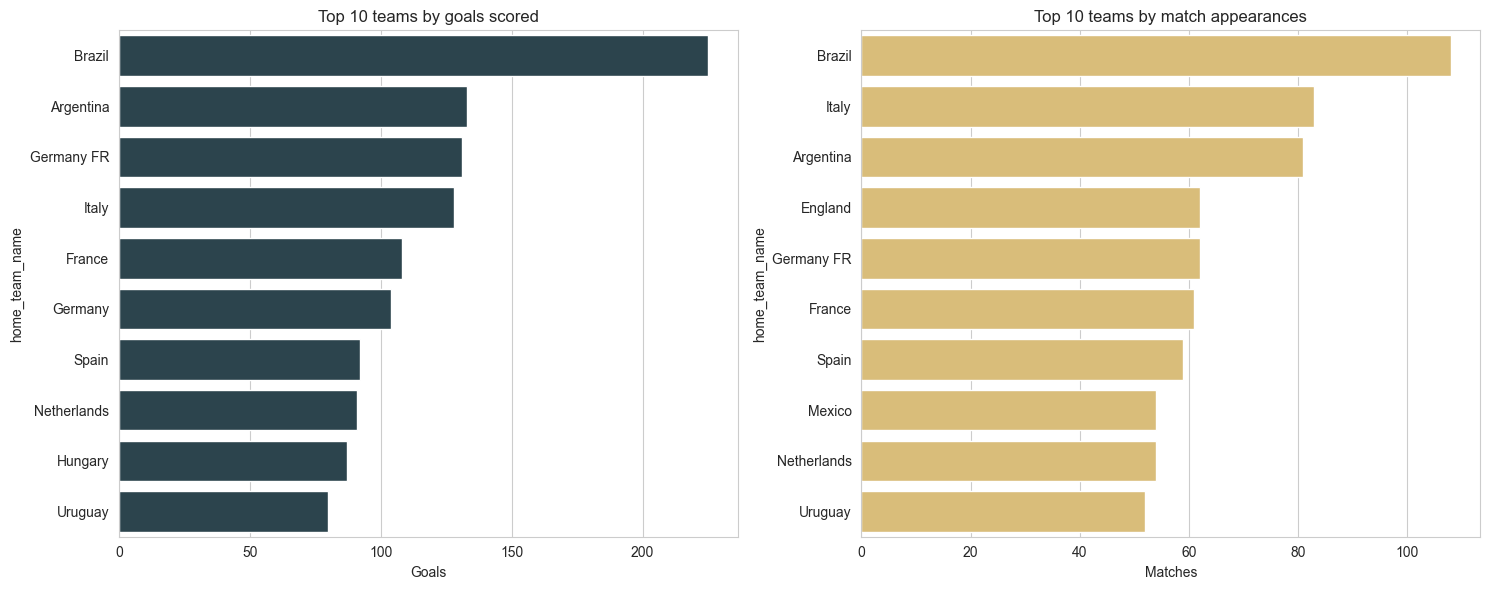

In [21]:

home_goals = eda_df.groupby("home_team_name")["home_team_goals"].sum()
away_goals = eda_df.groupby("away_team_name")["away_team_goals"].sum()
total_goals_by_team = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False).head(10)

home_apps = eda_df["home_team_name"].value_counts()
away_apps = eda_df["away_team_name"].value_counts()
total_apps = home_apps.add(away_apps, fill_value=0).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=total_goals_by_team.values, y=total_goals_by_team.index, ax=axes[0], color="#264653")
axes[0].set_title("Top 10 teams by goals scored")
axes[0].set_xlabel("Goals")

sns.barplot(x=total_apps.values, y=total_apps.index, ax=axes[1], color="#e9c46a")
axes[1].set_title("Top 10 teams by match appearances")
axes[1].set_xlabel("Matches")
plt.tight_layout()
plt.show()

/var/folders/kz/g7fm_pz11tv5kbttdpy6thc40000gn/T/ipykernel_46240/2155530086.py:13: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/fifa/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


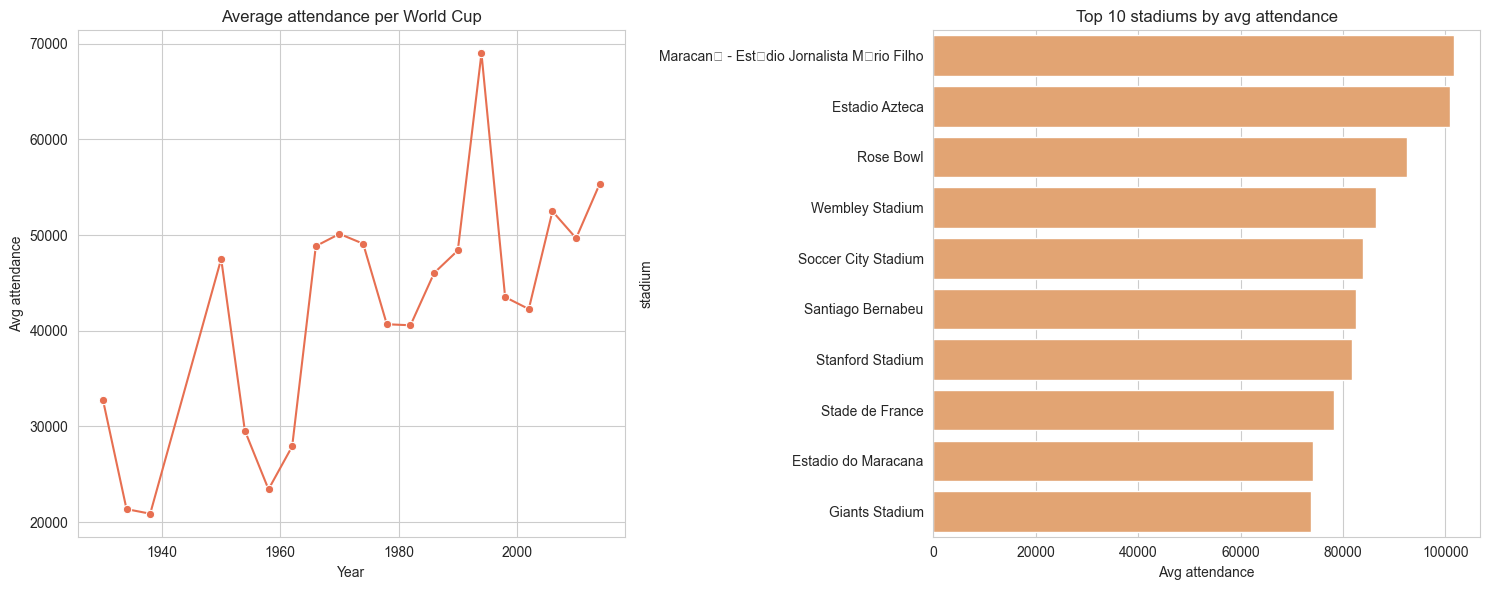

In [22]:

attendance_per_year = eda_df.groupby("year")["attendance"].mean()
top_stadiums = eda_df.groupby("stadium")["attendance"].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.lineplot(x=attendance_per_year.index, y=attendance_per_year.values, marker="o", ax=axes[0], color="#e76f51")
axes[0].set_title("Average attendance per World Cup")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg attendance")

sns.barplot(x=top_stadiums.values, y=top_stadiums.index, ax=axes[1], color="#f4a261")
axes[1].set_title("Top 10 stadiums by avg attendance")
axes[1].set_xlabel("Avg attendance")
plt.tight_layout()
plt.show()

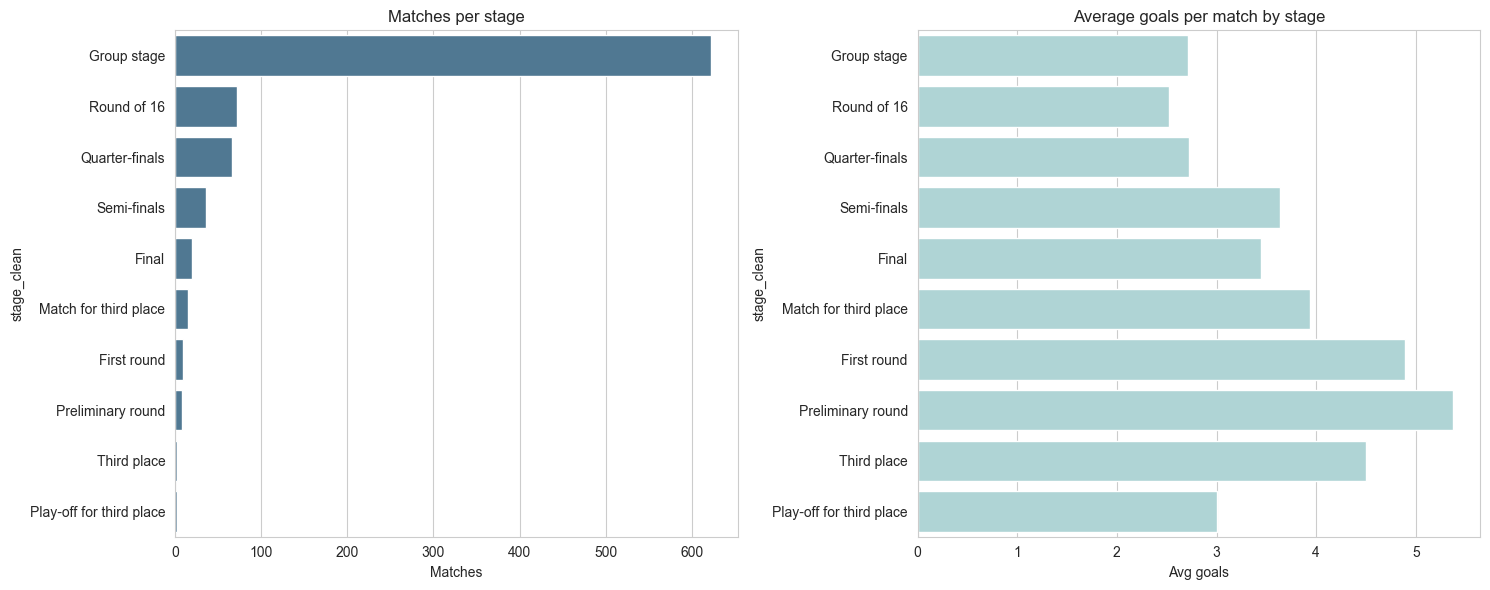

In [23]:

stage_clean = eda_df["stage"].str.replace(r"^Group \w+$", "Group stage", regex=True)
eda_s = eda_df.assign(stage_clean=stage_clean)

stage_counts = eda_s["stage_clean"].value_counts()
stage_goals = eda_s.groupby("stage_clean")["total_goals"].mean().reindex(stage_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=stage_counts.values, y=stage_counts.index, ax=axes[0], color="#457b9d")
axes[0].set_title("Matches per stage")
axes[0].set_xlabel("Matches")

sns.barplot(x=stage_goals.values, y=stage_goals.index, ax=axes[1], color="#a8dadc")
axes[1].set_title("Average goals per match by stage")
axes[1].set_xlabel("Avg goals")
plt.tight_layout()
plt.show()

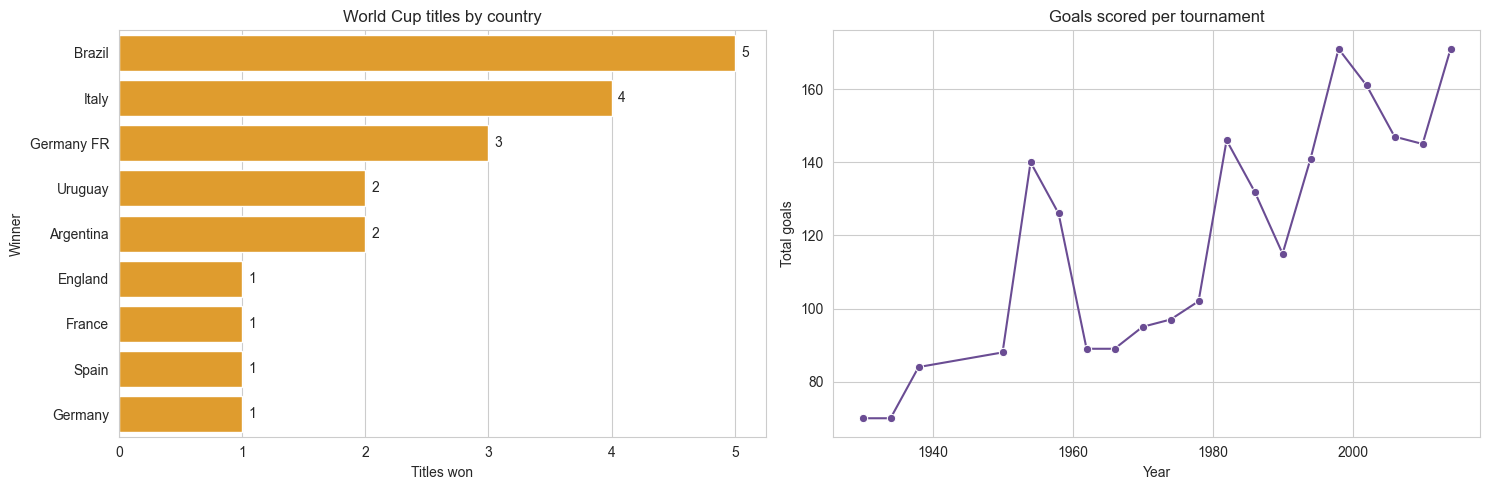

In [24]:
# === 8. Tournament winners (from WorldCups.csv) ===
# Switches to the tournament-level file (one row per World Cup).
cups = pd.read_csv(f"{DATA_DIR}/WorldCups.csv")
winner_counts = cups["Winner"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=winner_counts.values, y=winner_counts.index, ax=axes[0], color="#fca311")
axes[0].set_title("World Cup titles by country")
axes[0].set_xlabel("Titles won")
for i, v in enumerate(winner_counts.values):
    axes[0].text(v + 0.05, i, str(int(v)), va="center")

sns.lineplot(data=cups, x="Year", y="GoalsScored", marker="o", ax=axes[1], color="#6a4c93")
axes[1].set_title("Goals scored per tournament")
axes[1].set_ylabel("Total goals")
plt.tight_layout()
plt.show()

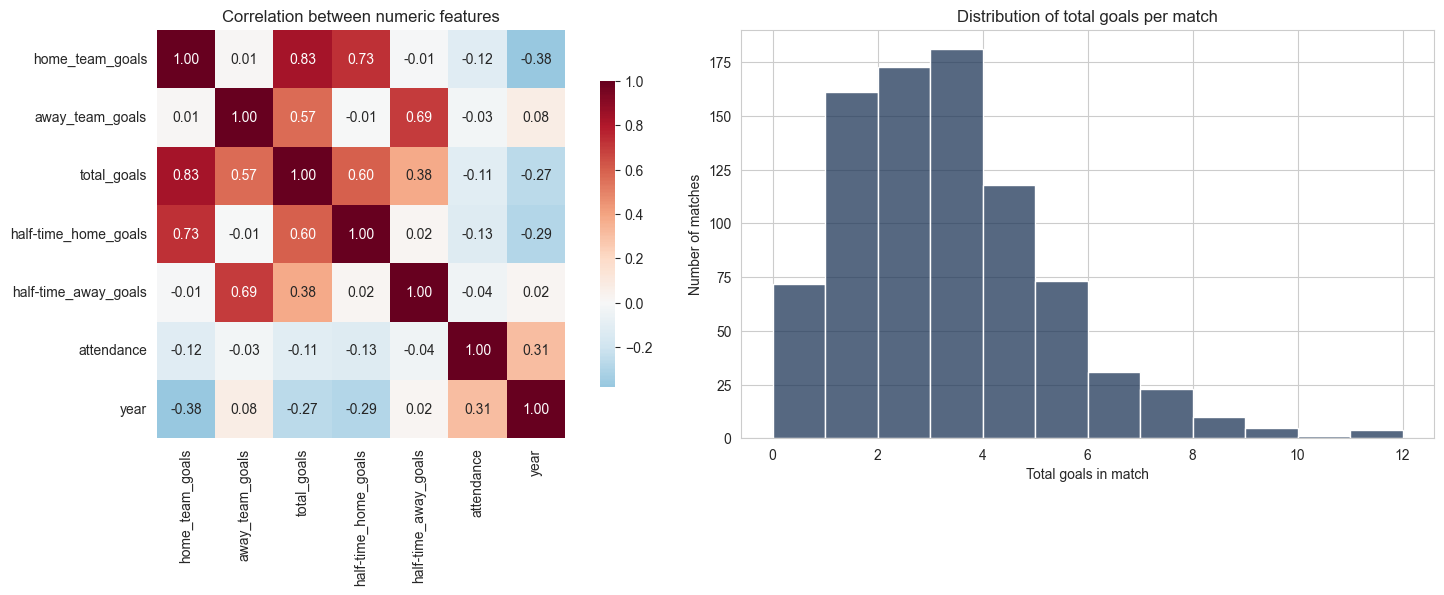

In [25]:

numeric_cols = ["home_team_goals", "away_team_goals", "total_goals",
                "half-time_home_goals", "half-time_away_goals",
                "attendance", "year"]
corr = eda_df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.75}, ax=axes[0])
axes[0].set_title("Correlation between numeric features")

sns.histplot(eda_df["total_goals"], bins=range(0, 13), ax=axes[1], color="#1d3557")
axes[1].set_title("Distribution of total goals per match")
axes[1].set_xlabel("Total goals in match")
axes[1].set_ylabel("Number of matches")
plt.tight_layout()
plt.show()

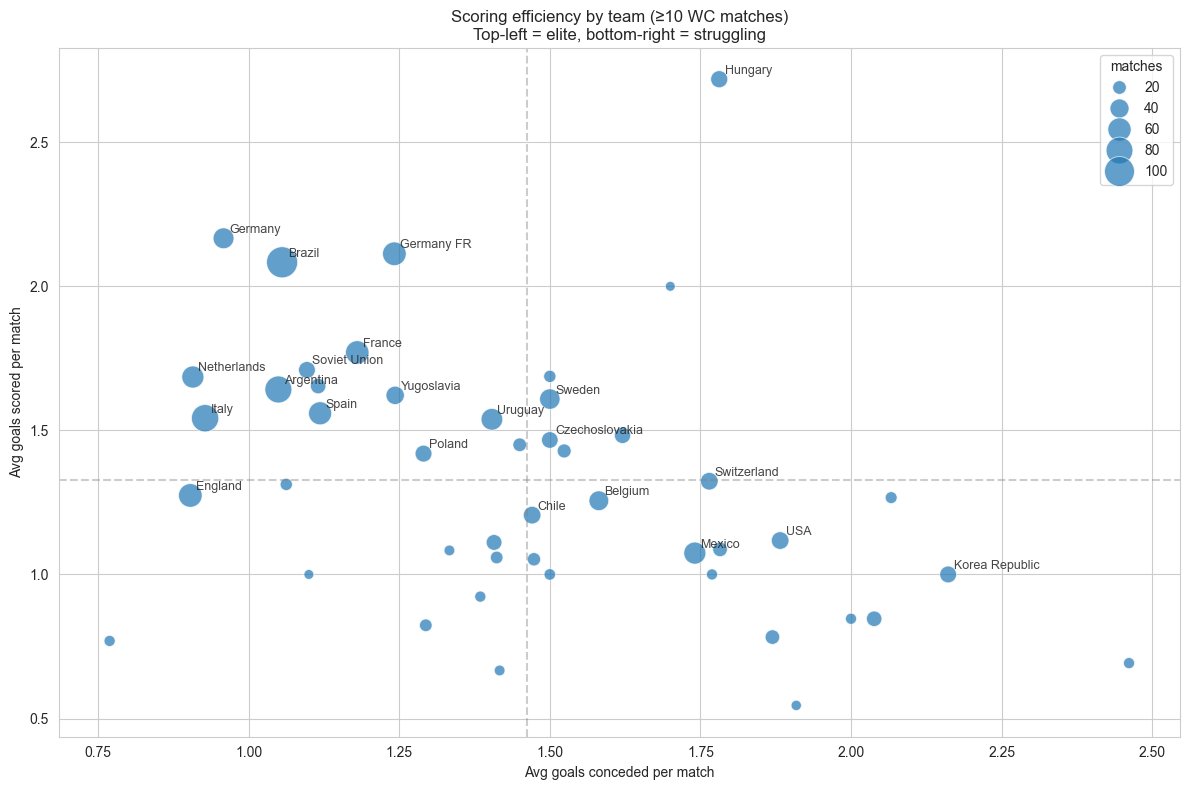

In [26]:

team_long = pd.concat([
    eda_df.rename(columns={"home_team_name": "team",
                            "home_team_goals": "goals_for",
                            "away_team_goals": "goals_against"})[["team", "goals_for", "goals_against"]],
    eda_df.rename(columns={"away_team_name": "team",
                            "away_team_goals": "goals_for",
                            "home_team_goals": "goals_against"})[["team", "goals_for", "goals_against"]],
], ignore_index=True)

team_stats_eda = team_long.groupby("team").agg(
    matches=("goals_for", "count"),
    avg_for=("goals_for", "mean"),
    avg_against=("goals_against", "mean"),
).reset_index()
team_stats_eda = team_stats_eda[team_stats_eda["matches"] >= 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=team_stats_eda, x="avg_against", y="avg_for",
                size="matches", sizes=(50, 500), alpha=0.7, legend="brief")
# Label only the heavy hitters so the chart isn't a wall of text.
for _, row in team_stats_eda.iterrows():
    if row["matches"] >= 30:
        plt.annotate(row["team"], (row["avg_against"], row["avg_for"]),
                     fontsize=9, alpha=0.85, xytext=(4, 4), textcoords="offset points")
plt.axhline(team_stats_eda["avg_for"].mean(), color="gray", linestyle="--", alpha=0.4)
plt.axvline(team_stats_eda["avg_against"].mean(), color="gray", linestyle="--", alpha=0.4)
plt.xlabel("Avg goals conceded per match")
plt.ylabel("Avg goals scored per match")
plt.title("Scoring efficiency by team (≥10 WC matches)\nTop-left = elite, bottom-right = struggling")
plt.tight_layout()
plt.show()

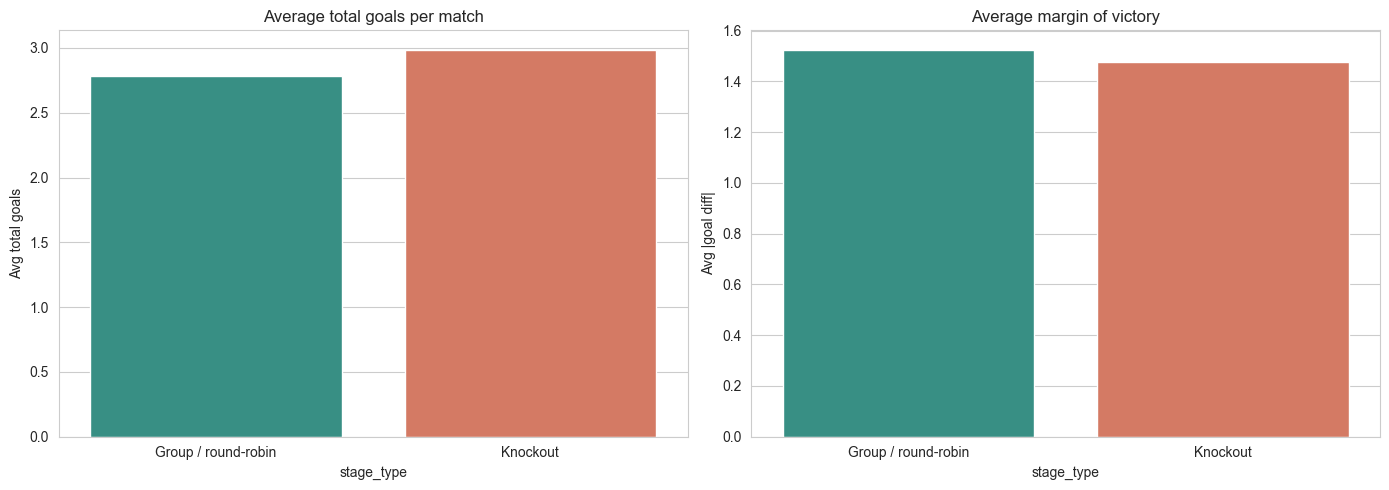

,stage_type,matches,avg_total_goals,avg_margin
0,Group / round-robin,639,2.782473,1.524257
1,Knockout,213,2.985915,1.474178


In [27]:

eda_df["is_knockout"] = ~eda_df["stage"].str.startswith("Group", na=False) & \
                       ~eda_df["stage"].str.contains("Preliminary", case=False, na=False) & \
                       ~eda_df["stage"].str.contains("First round", case=False, na=False)
eda_df["margin"] = (eda_df["home_team_goals"] - eda_df["away_team_goals"]).abs()

ko_summary = eda_df.groupby("is_knockout").agg(
    matches=("total_goals", "count"),
    avg_total_goals=("total_goals", "mean"),
    avg_margin=("margin", "mean"),
).reset_index()
ko_summary["stage_type"] = ko_summary["is_knockout"].map({True: "Knockout", False: "Group / round-robin"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=ko_summary, x="stage_type", y="avg_total_goals", ax=axes[0],
            hue="stage_type", palette=["#2a9d8f", "#e76f51"], legend=False)
axes[0].set_title("Average total goals per match")
axes[0].set_ylabel("Avg total goals")

sns.barplot(data=ko_summary, x="stage_type", y="avg_margin", ax=axes[1],
            hue="stage_type", palette=["#2a9d8f", "#e76f51"], legend=False)
axes[1].set_title("Average margin of victory")
axes[1].set_ylabel("Avg |goal diff|")
plt.tight_layout()
plt.show()
ko_summary[["stage_type", "matches", "avg_total_goals", "avg_margin"]]

In [28]:

initial_df["is_knockout"] = ~initial_df["stage"].str.startswith("Group", na=False) & \
                            ~initial_df["stage"].str.contains("Preliminary", case=False, na=False) & \
                            ~initial_df["stage"].str.contains("First round", case=False, na=False)

initial_df["decade"] = (initial_df["year"] // 10) * 10

initial_df[["stage", "is_knockout", "year", "decade"]].drop_duplicates(subset=["stage"]).head(15)

,stage,is_knockout,year,decade
0,Group 1,False,1930,1930
1,Group 4,False,1930,1930
2,Group 2,False,1930,1930
3,Group 3,False,1930,1930
15,Semi-finals,True,1930,1930
17,Final,True,1930,1930
18,Preliminary round,False,1934,1930
26,Quarter-finals,True,1934,1930
33,Match for third place,True,1934,1930
35,First round,False,1938,1930


In [29]:
# === Parse the datetime string + sort chronologically ===
# We need real chronological order before building rolling features so each
# match only "knows about" matches that came before it.
# The raw field looks like "13 Jul 1930 - 15:00"; we keep just the date part.
initial_df["match_date"] = pd.to_datetime(
    initial_df["datetime"].str.split(" - ").str[0],
    format="%d %b %Y",
    errors="coerce",
)
initial_df = initial_df.sort_values(["match_date", "year"]).reset_index(drop=True)

print("Date range:", initial_df["match_date"].min().date(), "→",
                     initial_df["match_date"].max().date())
initial_df[["match_date", "home_team_name", "away_team_name", "stage"]].head()

Date range: 1930-07-13 → 2014-07-13


,match_date,home_team_name,away_team_name,stage
0,1930-07-13,France,Mexico,Group 1
1,1930-07-13,USA,Belgium,Group 4
2,1930-07-14,Yugoslavia,Brazil,Group 2
3,1930-07-14,Romania,Peru,Group 3
4,1930-07-15,Argentina,France,Group 1


In [30]:
# === Time-aware team rolling features (CRITICAL — no data leakage) ===
# For each match, attach each team's running World Cup record *as of the moment
# just before this match*. We walk matches in chronological order and only
# update a team's totals AFTER recording the snapshot, so a match never sees
# its own outcome in its features.
#
# Why this matters for LinkedIn / interviews: a naive aggregation
# (e.g. "Brazil's career avg goals scored") leaks future info into the past
# — the model learns from results it shouldn't have known yet. This pattern
# is what makes the difference between an honest model and one that quietly
# memorizes the test set.
from collections import defaultdict

team_stats = defaultdict(lambda: {
    "matches": 0, "wins": 0, "draws": 0, "losses": 0,
    "goals_for": 0, "goals_against": 0,
})

def snapshot(team):
    s = team_stats[team]
    n = s["matches"]
    return {
        "matches_played":      n,
        "win_rate":             s["wins"] / n if n else 0.0,
        "draw_rate":            s["draws"] / n if n else 0.0,
        "avg_goals_for":        s["goals_for"] / n if n else 0.0,
        "avg_goals_against":    s["goals_against"] / n if n else 0.0,
        "goal_diff_per_match": (s["goals_for"] - s["goals_against"]) / n if n else 0.0,
    }

home_snaps, away_snaps = [], []
for _, row in initial_df.iterrows():
    home, away = row["home_team_name"], row["away_team_name"]
    hg, ag     = row["home_team_goals"], row["away_team_goals"]

    home_snaps.append(snapshot(home))
    away_snaps.append(snapshot(away))

    # Update AFTER the snapshot — keeps this match's outcome out of its own features.
    for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
        s = team_stats[team]
        s["matches"]       += 1
        s["goals_for"]     += gf
        s["goals_against"] += ga
        if gf > ga:   s["wins"]   += 1
        elif gf < ga: s["losses"] += 1
        else:         s["draws"]  += 1

home_features = pd.DataFrame(home_snaps).add_prefix("home_")
away_features = pd.DataFrame(away_snaps).add_prefix("away_")
initial_df = pd.concat([initial_df.reset_index(drop=True), home_features, away_features], axis=1)

# Spot-check: features for the latest few matches should reflect each team's
# full history minus the current match.
initial_df[["match_date", "home_team_name", "away_team_name",
            "home_matches_played", "home_win_rate",
            "away_matches_played", "away_win_rate"]].tail(8)

,match_date,home_team_name,away_team_name,home_matches_played,home_win_rate,away_matches_played,away_win_rate
844,NaT,Netherlands,Germany FR,53,0.547170,61,0.573770
845,NaT,Brazil,Turkey,107,0.654206,9,0.555556
846,NaT,China PR,Costa Rica,2,0.000000,16,0.250000
847,NaT,Japan,Belgium,16,0.250000,42,0.357143
848,NaT,Spain,Paraguay,58,0.482759,26,0.269231
849,NaT,Italy,Croatia,82,0.548780,15,0.400000
850,NaT,Senegal,Uruguay,4,0.500000,51,0.392157
851,NaT,Mexico,USA,53,0.264151,33,0.212121


In [31]:
# === World Cup 2026 group composition (actual draw) ===
# 48 teams across 12 groups (A-L) of 4. Top 2 from each group + the 8 best
# 3rd-placed teams advance to a 32-team round of 16.
#
# Source: FIFA-released matchday-1 fixtures. The two games in each group on
# matchday 1 pair up A1-A2 and A3-A4, so the fixture list uniquely identifies
# the four teams per group.
wc2026_groups = {
    "A": ["Czech Republic", "Mexico",                "South Africa",  "Korea Republic"],
    "B": ["Switzerland",    "Canada",                "Bosnia and Herzegovina", "Qatar"],
    "C": ["Scotland",       "Brazil",                "Morocco",       "Haiti"],
    "D": ["Turkey",         "USA",                   "Paraguay",      "Australia"],
    "E": ["Ecuador",        "Germany",               "Curacao",       "Cote d'Ivoire"],
    "F": ["Tunisia",        "Netherlands",           "Japan",         "Sweden"],
    "G": ["New Zealand",    "Belgium",               "Egypt",         "IR Iran"],
    "H": ["Uruguay",        "Spain",                 "Cape Verde",    "Saudi Arabia"],
    "I": ["Norway",         "France",                "Senegal",       "Iraq"],
    "J": ["Jordan",         "Argentina",             "Algeria",       "Austria"],
    "K": ["Colombia",       "Portugal",              "DR Congo",      "Uzbekistan"],
    "L": ["Panama",         "England",               "Croatia",       "Ghana"],
}

# Sanity-check #1: structure (48 unique teams, 12 groups of 4).
all_teams = [t for teams in wc2026_groups.values() for t in teams]
assert len(all_teams) == 48 and len(set(all_teams)) == 48, "duplicate or missing teams"

# Sanity-check #2: which 2026 teams DO NOT appear in our historical dataset?
# These will have zero-history features and the model will treat them as
# unknown underdogs. Names sometimes differ between sources too (e.g. our CSV
# may use "Iran" rather than "IR Iran") — anything flagged here either needs
# a name fix below, or is a first-time/long-absent qualifier we'll flag.
historical_teams = set(initial_df["home_team_name"]).union(initial_df["away_team_name"])
missing = sorted(set(all_teams) - historical_teams)
print(f"{len(missing)} of 48 teams not found in historical WC data:")
for t in missing:
    print(f"  • {t}")

# Display groups in a clean table.
groups_df = pd.DataFrame(wc2026_groups).T
groups_df.columns = ["Team 1", "Team 2", "Team 3", "Team 4"]
groups_df.index.name = "Group"
groups_df

9 of 48 teams not found in historical WC data:
  • Bosnia and Herzegovina
  • Cape Verde
  • Cote d'Ivoire
  • Curacao
  • DR Congo
  • Jordan
  • Panama
  • Qatar
  • Uzbekistan


,Team 1,Team 2,Team 3,Team 4
Group,,,,
A,Czech Republic,Mexico,South Africa,Korea Republic
B,Switzerland,Canada,Bosnia and Herzegovina,Qatar
C,Scotland,Brazil,Morocco,Haiti
D,Turkey,USA,Paraguay,Australia
E,Ecuador,Germany,Curacao,Cote d'Ivoire
F,Tunisia,Netherlands,Japan,Sweden
G,New Zealand,Belgium,Egypt,IR Iran
H,Uruguay,Spain,Cape Verde,Saudi Arabia
I,Norway,France,Senegal,Iraq


In [32]:
# === Generate the round-robin schedule for each WC 2026 group ===
# In a 4-team round-robin each pair plays once: C(4,2) = 6 matches per group,
# 6 × 12 = 72 group-stage matches in total.
from itertools import combinations

group_matches = []
for group, teams in wc2026_groups.items():
    for t1, t2 in combinations(teams, 2):
        group_matches.append({"group": group, "team_a": t1, "team_b": t2})

group_matches_df = pd.DataFrame(group_matches)
print(f"Generated {len(group_matches_df)} group-stage matches across {len(wc2026_groups)} groups")
group_matches_df.head(12)

Generated 72 group-stage matches across 12 groups


,group,team_a,team_b
0,A,Czech Republic,Mexico
1,A,Czech Republic,South Africa
2,A,Czech Republic,Korea Republic
3,A,Mexico,South Africa
4,A,Mexico,Korea Republic
5,A,South Africa,Korea Republic
6,B,Switzerland,Canada
7,B,Switzerland,Bosnia and Herzegovina
8,B,Switzerland,Qatar
9,B,Canada,Bosnia and Herzegovina


In [33]:
# === Modeling dataset: features + target, leak-free ===
# Target: `result` (Home Win / Away Win / Draw) — 3-class classification.
#
# Features: ONLY the time-aware team-history columns + stage type.
# We deliberately exclude every goal column (home_team_goals, half-time goals,
# total_goals, goal_difference, ...) because those describe the match outcome
# itself — including them would let the model "cheat" by looking at the answer.
#
# We also require both teams to have at least 3 prior WC matches; otherwise the
# rolling features are mostly zeros and the model can't learn anything useful
# (e.g. a debutant playing Brazil — features carry no signal for the debutant).
feature_cols = [
    "home_matches_played", "home_win_rate", "home_draw_rate",
    "home_avg_goals_for", "home_avg_goals_against", "home_goal_diff_per_match",
    "away_matches_played", "away_win_rate", "away_draw_rate",
    "away_avg_goals_for", "away_avg_goals_against", "away_goal_diff_per_match",
    "is_knockout",
]

mask = (initial_df["home_matches_played"] >= 3) & (initial_df["away_matches_played"] >= 3)
model_df = initial_df.loc[mask, feature_cols + ["result", "year"]].copy()
model_df["is_knockout"] = model_df["is_knockout"].astype(int)

print(f"Modeling dataset: {len(model_df)} matches (filtered from {len(initial_df)})")
print(f"Features: {len(feature_cols)}\n")
print("Target distribution:")
print(model_df["result"].value_counts(normalize=True).round(3))
model_df.head()

Modeling dataset: 646 matches (filtered from 852)
Features: 13

Target distribution:
result
Home Win    0.548
Draw        0.237
Away Win    0.215
Name: proportion, dtype: float64


,home_matches_played,home_win_rate,home_draw_rate,home_avg_goals_for,home_avg_goals_against,home_goal_diff_per_match,away_matches_played,away_win_rate,away_draw_rate,away_avg_goals_for,away_avg_goals_against,away_goal_diff_per_match,is_knockout,result,year
17,3,1.000000,0.000000,3.666667,0.333333,3.333333,4,1.000000,0.0,4.000000,1.250000,2.750000,1,Home Win,1930
33,3,0.666667,0.000000,2.666667,2.000000,0.666667,3,0.666667,0.0,1.666667,1.333333,0.333333,1,Home Win,1934
34,4,0.750000,0.250000,2.500000,0.500000,2.000000,3,1.000000,0.0,2.666667,1.333333,1.333333,1,Home Win,1934
37,4,0.250000,0.000000,1.500000,1.500000,0.000000,3,0.000000,0.0,0.666667,3.000000,-2.333333,0,Home Win,1938
43,3,0.333333,0.333333,2.000000,2.000000,0.000000,5,0.600000,0.2,2.400000,1.800000,0.600000,0,Home Win,1938


In [34]:
# === Reconcile 2026 team names with their historical-dataset names ===
# A few 2026 qualifiers appear under different names in our historical CSV.
# We do two things here:
#   1. DIAGNOSTIC: for each "missing" team, print historical names that share
#      a keyword so the user can confirm the right alias.
#   2. APPLY remaps to the `team_stats` accumulator so the 2026 lookup hits.
#      (Cheap — it's just re-keying a dict.)
historical_unique = sorted(set(initial_df["home_team_name"]).union(initial_df["away_team_name"]))

print("=== Candidate matches in historical data ===")
for t in missing:
    # Try to find historical names sharing any token with the target
    target_tokens = t.lower().replace("'", " ").replace("-", " ").split()
    hits = [h for h in historical_unique
            if any(tok in h.lower() for tok in target_tokens if len(tok) > 3)]
    print(f"  '{t}'  candidates: {hits}")

# Step 2: apply the renames we've confirmed (or want to assume).
# Add to this dict and re-run if the diagnostic above suggests other matches.
NAME_REMAP = {
    "Côte d'Ivoire":          "Cote d'Ivoire",          # accent variation
    "Zaire":                   "DR Congo",                # historical name of DR Congo
    "Bosnia and Herzegovina":  "Bosnia and Herzegovina", # no-op safeguard
}

remapped = 0
for old, new in NAME_REMAP.items():
    if old in team_stats and old != new:
        team_stats[new] = team_stats[old]
        remapped += 1
        print(f"  ✓ team_stats remapped: '{old}' → '{new}'")

print(f"\nApplied {remapped} renames. True newcomers (no WC history, even after renames):")
still_missing = sorted(set(all_teams) - set(team_stats.keys()))
for t in still_missing:
    print(f"  • {t}")

=== Candidate matches in historical data ===
  'Bosnia and Herzegovina'  candidates: ['rn">Bosnia and Herzegovina']
  'Cape Verde'  candidates: []
  'Cote d'Ivoire'  candidates: ["C�te d'Ivoire"]
  'Curacao'  candidates: []
  'DR Congo'  candidates: []
  'Jordan'  candidates: []
  'Panama'  candidates: []
  'Qatar'  candidates: []
  'Uzbekistan'  candidates: []
  ✓ team_stats remapped: 'Zaire' → 'DR Congo'

Applied 1 renames. True newcomers (no WC history, even after renames):
  • Bosnia and Herzegovina
  • Cape Verde
  • Cote d'Ivoire
  • Curacao
  • Jordan
  • Panama
  • Qatar
  • Uzbekistan


In [35]:
# === Phase 2 setup: imports + time-based train/test split ===
# scikit-learn is pre-installed on Kaggle.
#
# Time-based split is critical for football: a random split would leak info
# from later tournaments into the training set. We hold out the LATEST 2 World
# Cups (2010 + 2014) and train on everything before.
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, log_loss, f1_score,
                              classification_report, confusion_matrix,
                              roc_curve, auc)
import warnings
warnings.filterwarnings("ignore")

years_sorted = sorted(model_df["year"].unique())
test_years = years_sorted[-2:]
train_years = years_sorted[:-2]
print(f"Train years: {train_years[0]} - {train_years[-1]}  ({len(train_years)} tournaments)")
print(f"Test years:  {test_years}")

train_df = model_df[~model_df["year"].isin(test_years)].copy()
test_df  = model_df[ model_df["year"].isin(test_years)].copy()

X_train, y_train = train_df[feature_cols].values, train_df["result"].values
X_test,  y_test  = test_df[feature_cols].values,  test_df["result"].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain matches: {len(X_train)}  |  Test matches: {len(X_test)}")
print("\nClass balance (train set):")
print(pd.Series(y_train).value_counts(normalize=True).round(3))


Train years: 1930 - 2006  (18 tournaments)
Test years:  [np.int64(2010), np.int64(2014)]

Train matches: 511  |  Test matches: 135

Class balance (train set):
Home Win    0.585
Draw        0.237
Away Win    0.178
Name: proportion, dtype: float64


In [36]:
# === Train 4 models on the same training set ===
# We try diverse model families so the comparison is meaningful:
#   - Logistic Regression     : linear baseline (uses scaled features)
#   - Random Forest           : bagging of decision trees, robust + interpretable
#   - Gradient Boosting       : classic sklearn boosting — sequential tree refinement
#   - HistGradient Boosting   : modern histogram-binned boosting, faster + often better
models = {
    "Logistic Regression":   LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=300, max_depth=8,
                                                     min_samples_leaf=5, random_state=42),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                         learning_rate=0.05, random_state=42),
    "HistGradient Boosting":  HistGradientBoostingClassifier(max_iter=300, max_depth=5,
                                                              learning_rate=0.05, random_state=42),
}

trained = {}
for name, mdl in models.items():
    Xtr = X_train_s if name == "Logistic Regression" else X_train
    mdl.fit(Xtr, y_train)
    trained[name] = mdl
    print(f"  ✓ {name}")

  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ HistGradient Boosting


In [37]:
# === Evaluate all 4 models on the held-out test set ===
# Three complementary metrics:
#  - Accuracy  : easy to read but biased toward the majority class (Home Win ~55%)
#  - Macro F1  : averages F1 across the 3 outcomes — treats Home/Draw/Away equally
#  - Log Loss  : rewards well-calibrated probabilities (not just hard predictions)
classes = trained["Logistic Regression"].classes_

def evaluate(name, mdl):
    Xte = X_test_s if name == "Logistic Regression" else X_test
    preds = mdl.predict(Xte)
    probs = mdl.predict_proba(Xte)
    return {
        "model":    name,
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
        "log_loss": log_loss(y_test, probs, labels=classes),
        "preds":    preds,
        "probs":    probs,
    }

results = {name: evaluate(name, mdl) for name, mdl in trained.items()}
metrics_df = pd.DataFrame([
    {"Model": r["model"],
     "Accuracy": round(r["accuracy"], 3),
     "Macro F1": round(r["macro_f1"], 3),
     "Log Loss": round(r["log_loss"], 3)}
    for r in results.values()
]).sort_values("Macro F1", ascending=False).reset_index(drop=True)

print(f"Test set: {len(y_test)} matches")
metrics_df

Test set: 135 matches


,Model,Accuracy,Macro F1,Log Loss
0,Gradient Boosting,0.467,0.445,1.156
1,Random Forest,0.467,0.408,1.006
2,Logistic Regression,0.452,0.388,1.102
3,HistGradient Boosting,0.400,0.379,1.575


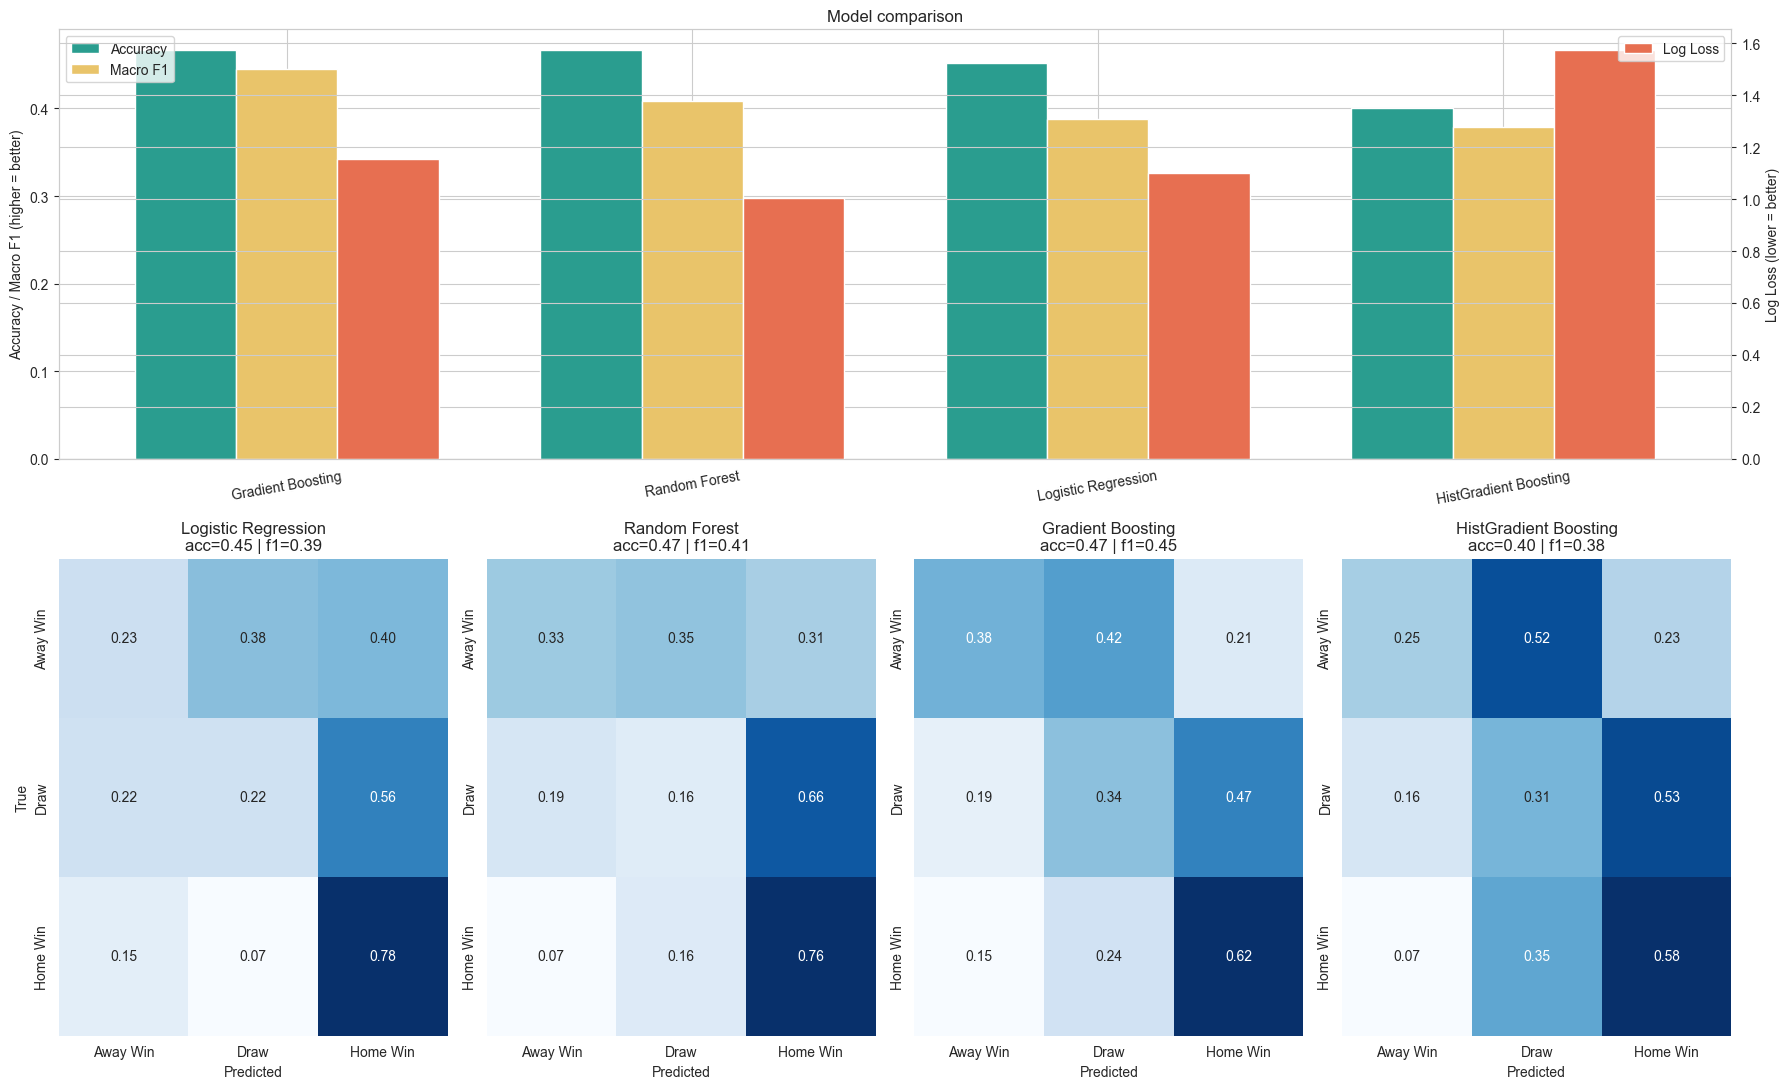

In [38]:
# === Visual model comparison: metric bars + per-model confusion matrices ===
# Top row: metric comparison across the 4 models. Accuracy & Macro F1 on one
# y-axis (higher = better), Log Loss on a secondary axis (lower = better).
# Bottom row: row-normalized confusion matrix per model — diagonal-heaviness
# = good per-class recall.
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 4, height_ratios=[0.9, 1])

ax = fig.add_subplot(gs[0, :])
x = np.arange(len(metrics_df))
w = 0.25
ax.bar(x - w, metrics_df["Accuracy"], w, label="Accuracy",  color="#2a9d8f")
ax.bar(x,     metrics_df["Macro F1"], w, label="Macro F1",  color="#e9c46a")
ax2 = ax.twinx()
ax2.bar(x + w, metrics_df["Log Loss"], w, label="Log Loss", color="#e76f51")
ax.set_xticks(x); ax.set_xticklabels(metrics_df["Model"], rotation=10)
ax.set_ylabel("Accuracy / Macro F1 (higher = better)")
ax2.set_ylabel("Log Loss (lower = better)")
ax.set_title("Model comparison")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")

for i, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test, r["preds"], labels=classes, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=classes, yticklabels=classes, cbar=False, ax=ax)
    ax.set_title(f"{name}\nacc={r['accuracy']:.2f} | f1={r['macro_f1']:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if i == 0 else "")

plt.tight_layout()
plt.show()

In [ ]:
# === Feature importance + ROC curves for the best model ===
# - Feature importance (Random Forest): tells us which inputs the trees split
#   on most often — useful for the LinkedIn writeup ("the model cares about X").
# - Multi-class ROC: one-vs-rest curve per outcome class. Closer to top-left
#   corner = better. AUC of 0.5 = no signal; 1.0 = perfect.
best_name = metrics_df.iloc[0]["Model"]
best = results[best_name]
print(f"Best model: {best_name}  (macro F1 = {best['macro_f1']:.3f}, log_loss = {best['log_loss']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Feature importance from Random Forest (always exposed).
rf = trained["Random Forest"]
imp = pd.DataFrame({"feature": feature_cols,
                    "importance": rf.feature_importances_}).sort_values("importance")
sns.barplot(data=imp, x="importance", y="feature", ax=axes[0], color="#264653")
axes[0].set_title("Feature importance (Random Forest)")
axes[0].set_xlabel("Importance")

# Multi-class ROC for best model — one curve per outcome class.
y_test_bin = label_binarize(y_test, classes=classes)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best["probs"][:, i])
    axes[1].plot(fpr, tpr, label=f"{cls}  (AUC = {auc(fpr, tpr):.2f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title(f"ROC curves — {best_name} (one-vs-rest)")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nDetailed classification report (best model on test set):")
print(classification_report(y_test, best["preds"]))

In [39]:
# === Snapshot each team's current career features for 2026 prediction ===
# The team_stats accumulator (from the rolling-features cell) now holds each
# team's *all-time* WC career. Reading it now gives the right feature vector
# to plug into the model for any 2026 fixture.
def current_features(team):
    s = team_stats.get(team, {"matches": 0, "wins": 0, "draws": 0,
                              "losses": 0, "goals_for": 0, "goals_against": 0})
    n = s["matches"]
    return {
        "matches_played":      n,
        "win_rate":             s["wins"] / n if n else 0.0,
        "draw_rate":            s["draws"] / n if n else 0.0,
        "avg_goals_for":        s["goals_for"] / n if n else 0.0,
        "avg_goals_against":    s["goals_against"] / n if n else 0.0,
        "goal_diff_per_match": (s["goals_for"] - s["goals_against"]) / n if n else 0.0,
    }

# For first-time 2026 qualifiers (Jordan, Curacao, Cape Verde, Uzbekistan,
# Panama, Qatar) we use the *median established team* as a neutral prior —
# treats them as an "average team", not an automatic underdog.
ESTABLISHED = [t for t, s in team_stats.items() if s["matches"] >= 5]
median_team = pd.DataFrame([current_features(t) for t in ESTABLISHED]).median().to_dict()

def features_for_team(team):
    f = current_features(team)
    if f["matches_played"] == 0:
        # Newcomer → median-team prior, but keep matches_played=0 as a signal.
        return {**median_team, "matches_played": 0}
    return f

print("Sanity check (elite / mid / newcomer / remapped):")
for t in ["Brazil", "Mexico", "Jordan", "DR Congo", "Cote d'Ivoire"]:
    f = features_for_team(t)
    print(f"  {t:>22s}: played={int(f['matches_played']):>3d}  win_rate={f['win_rate']:.2f}  gd/match={f['goal_diff_per_match']:+.2f}")

Sanity check (elite / mid / newcomer / remapped):
                  Brazil: played=108  win_rate=0.66  gd/match=+1.03
                  Mexico: played= 54  win_rate=0.26  gd/match=-0.67
                  Jordan: played=  0  win_rate=0.32  gd/match=-0.25
                DR Congo: played=  3  win_rate=0.00  gd/match=-4.67
           Cote d'Ivoire: played=  0  win_rate=0.32  gd/match=-0.25


In [40]:
# === Predict every group-stage match using the best model ===
def build_match_row(team_a, team_b, is_knockout=False):
    a = features_for_team(team_a)
    b = features_for_team(team_b)
    return [
        a["matches_played"], a["win_rate"], a["draw_rate"],
        a["avg_goals_for"], a["avg_goals_against"], a["goal_diff_per_match"],
        b["matches_played"], b["win_rate"], b["draw_rate"],
        b["avg_goals_for"], b["avg_goals_against"], b["goal_diff_per_match"],
        int(is_knockout),
    ]

def predict_match(team_a, team_b, is_knockout=False, model_name=None):
    name = model_name or best_name
    X = np.array([build_match_row(team_a, team_b, is_knockout)])
    if name == "Logistic Regression":
        X = scaler.transform(X)
    probs = trained[name].predict_proba(X)[0]
    return dict(zip(classes, probs))

predictions = []
for _, row in group_matches_df.iterrows():
    p = predict_match(row["team_a"], row["team_b"], is_knockout=False)
    predictions.append({
        "group":     row["group"],
        "team_a":    row["team_a"],
        "team_b":    row["team_b"],
        "p_home":    round(p["Home Win"], 3),
        "p_draw":    round(p["Draw"], 3),
        "p_away":    round(p["Away Win"], 3),
        "predicted": max(p, key=p.get),
    })

predictions_df = pd.DataFrame(predictions)
print(f"Predicted {len(predictions_df)} group matches using {best_name}\n")
predictions_df.head(12)

NameError: name 'best_name' is not defined

In [ ]:
# === Convert predicted match outcomes into group standings ===
# Standard FIFA scoring: win = 3 points, draw = 1, loss = 0.
# Tie-break: we use each team's historical goal_diff_per_match as a proxy
# (we're predicting outcome only, not scoreline, so this stands in for GD).
standings = []
for group, teams in wc2026_groups.items():
    pts = {t: 0 for t in teams}
    for _, m in predictions_df[predictions_df["group"] == group].iterrows():
        if   m["predicted"] == "Home Win": pts[m["team_a"]] += 3
        elif m["predicted"] == "Away Win": pts[m["team_b"]] += 3
        else:
            pts[m["team_a"]] += 1
            pts[m["team_b"]] += 1

    rank = sorted(teams,
                  key=lambda t: (pts[t], features_for_team(t)["goal_diff_per_match"]),
                  reverse=True)
    for pos, t in enumerate(rank, 1):
        standings.append({
            "group": group, "position": pos,
            "team": t, "points": pts[t],
            "gd_proxy": round(features_for_team(t)["goal_diff_per_match"], 2),
        })

standings_df = pd.DataFrame(standings)
group_winners = standings_df[standings_df["position"] == 1].set_index("group")["team"]
runners_up    = standings_df[standings_df["position"] == 2].set_index("group")["team"]

print("=== Predicted group winners ===")
for g, t in group_winners.items():
    print(f"  Group {g}: {t}")
print("\n=== Predicted runners-up ===")
for g, t in runners_up.items():
    print(f"  Group {g}: {t}")

In [ ]:
# === 12 mini-standings, one per group ===
# Color coding: green = winner, light-blue = runner-up, amber = 3rd, red = eliminated.
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
pos_color = {1: "#2a9d8f", 2: "#a8dadc", 3: "#e9c46a", 4: "#e76f51"}

for i, group in enumerate(sorted(wc2026_groups.keys())):
    grp = standings_df[standings_df["group"] == group].sort_values("position")
    bars = axes[i].barh(grp["team"], grp["points"],
                         color=[pos_color[p] for p in grp["position"]])
    axes[i].set_title(f"Group {group}")
    axes[i].set_xlabel("Points")
    axes[i].invert_yaxis()
    for bar, pts in zip(bars, grp["points"]):
        axes[i].text(pts + 0.1, bar.get_y() + bar.get_height() / 2,
                     str(int(pts)), va="center")

plt.suptitle("WC 2026 — Predicted group standings\n"
             "Green = winner, blue = runner-up, amber = 3rd, red = eliminated",
             fontsize=15, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
import os
intl_path = "/Users/mouyasushi/Desktop/fifa/worldCup/intl"
print("Dataset path:", intl_path)
print("Files:", os.listdir(intl_path))


In [ ]:
# === Load and sort the international-matches dataset ===
intl = pd.read_csv(os.path.join(intl_path, "results.csv"))
intl["date"] = pd.to_datetime(intl["date"])
intl = intl.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(intl):,} international matches")
print(f"Date range: {intl['date'].min().date()} -> {intl['date'].max().date()}")
print("\nTop tournament types:")
print(intl["tournament"].value_counts().head(10))
intl.head()


In [ ]:
# === Build ELO ratings through the entire history (~45K matches) ===
# Standard ELO with a tournament-importance K-factor + a goal-difference
# multiplier. Each team's rating updates after every match based on the
# result vs. the expected result given current ratings.
#
# Why ELO is the right call here:
#   - Captures recency (recent matches matter more than old ones)
#   - Accounts for opponent strength (beating Brazil > beating San Marino)
#   - One number replaces v1's whole "rolling career averages" approach
K_BY_TOURNAMENT = {
    "FIFA World Cup":               60,
    "FIFA World Cup qualification": 30,
    "UEFA Euro":                    40,
    "UEFA Euro qualification":      25,
    "Copa America":                 40,
    "African Cup of Nations":       35,
    "AFC Asian Cup":                35,
    "Gold Cup":                     30,
    "Confederations Cup":           35,
    "Friendly":                     20,
}

def k_factor(tournament):
    t = str(tournament).lower()
    for key, k in K_BY_TOURNAMENT.items():
        if key.lower() in t:
            return k
    return 25  # default for unknown tournament types

def expected(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))

elo = defaultdict(lambda: 1500.0)
home_elos, away_elos = [], []

for _, m in intl.iterrows():
    home, away = m["home_team"], m["away_team"]
    hg, ag = m["home_score"], m["away_score"]

    # Snapshot BEFORE the update so each row stores pre-game ELO (no leakage)
    home_elos.append(elo[home])
    away_elos.append(elo[away])

    if pd.isna(hg) or pd.isna(ag):
        continue

    k = k_factor(m["tournament"])
    # Goal-difference multiplier: a 4-0 wallop moves ELO more than a 1-0
    margin = abs(hg - ag)
    mult = 1.0 if margin <= 1 else (1.5 if margin == 2 else 1.75 + (margin - 3) / 8)

    if   hg > ag: score_a = 1.0
    elif hg < ag: score_a = 0.0
    else:         score_a = 0.5

    delta = k * mult * (score_a - expected(elo[home], elo[away]))
    elo[home] += delta
    elo[away] -= delta

intl["home_elo_pre"] = home_elos
intl["away_elo_pre"] = away_elos

# Quick check: top teams by current ELO
top15 = sorted(elo.items(), key=lambda x: -x[1])[:15]
print("=== Top 15 teams by current ELO ===")
for t, r in top15:
    print(f"  {t:>22s}: {r:.0f}")


In [ ]:
# === Recent-form features: each team's last-10-match record ===
# ELO is great but smooths out short-term form. Layering in last-10 stats
# tells the model how a team is playing *right now*, vital just before a
# major tournament.
from collections import deque

FORM_WINDOW = 10
team_form = defaultdict(lambda: deque(maxlen=FORM_WINDOW))  # entries: (gf, ga)

home_form_wr, home_form_gf, home_form_ga = [], [], []
away_form_wr, away_form_gf, away_form_ga = [], [], []

def form_snapshot(team):
    fm = team_form[team]
    if len(fm) < 3:                  # too few matches -> neutral prior
        return 0.4, 1.2, 1.2
    wins = sum(1 for gf, ga in fm if gf > ga)
    return (wins / len(fm),
            sum(g for g, _ in fm) / len(fm),
            sum(a for _, a in fm) / len(fm))

for _, m in intl.iterrows():
    home, away = m["home_team"], m["away_team"]
    hg, ag = m["home_score"], m["away_score"]

    hwr, hgf, hga = form_snapshot(home)
    awr, agf, aga = form_snapshot(away)
    home_form_wr.append(hwr); home_form_gf.append(hgf); home_form_ga.append(hga)
    away_form_wr.append(awr); away_form_gf.append(agf); away_form_ga.append(aga)

    if pd.isna(hg) or pd.isna(ag):
        continue
    team_form[home].append((hg, ag))
    team_form[away].append((ag, hg))

intl["home_form_wr"] = home_form_wr
intl["home_form_gf"] = home_form_gf
intl["home_form_ga"] = home_form_ga
intl["away_form_wr"] = away_form_wr
intl["away_form_gf"] = away_form_gf
intl["away_form_ga"] = away_form_ga

print("Form features built.")
intl[["date", "home_team", "away_team",
      "home_elo_pre", "away_elo_pre",
      "home_form_wr", "away_form_wr"]].tail()


In [ ]:
# === v2 modeling dataset + time-based train/test split ===
# Focus on 1980+ (modern football era). Hold out matches from 2019 onward as
# the test set -- mirrors how we'd actually use the model: train on past,
# evaluate on the future.
intl_model = intl.dropna(subset=["home_score", "away_score"]).copy()
intl_model = intl_model[intl_model["date"] >= "1980-01-01"]

intl_model["result"] = np.where(
    intl_model["home_score"] > intl_model["away_score"], "Home Win",
    np.where(intl_model["home_score"] < intl_model["away_score"], "Away Win", "Draw")
)

intl_model["elo_diff"]       = intl_model["home_elo_pre"] - intl_model["away_elo_pre"]
intl_model["form_wr_diff"]   = intl_model["home_form_wr"] - intl_model["away_form_wr"]
intl_model["is_neutral"]     = intl_model["neutral"].astype(int)
intl_model["is_competitive"] = (~intl_model["tournament"].str.contains(
    "Friendly", case=False, na=False)).astype(int)

feature_cols_v2 = [
    "home_elo_pre", "away_elo_pre", "elo_diff",
    "home_form_wr", "away_form_wr", "form_wr_diff",
    "home_form_gf", "home_form_ga",
    "away_form_gf", "away_form_ga",
    "is_neutral", "is_competitive",
]

model_df_v2 = intl_model[feature_cols_v2 + ["result", "date"]].copy()

cutoff = pd.Timestamp("2019-01-01")
train_v2 = model_df_v2[model_df_v2["date"] <  cutoff]
test_v2  = model_df_v2[model_df_v2["date"] >= cutoff]

X_train_v2 = train_v2[feature_cols_v2].values
y_train_v2 = train_v2["result"].values
X_test_v2  = test_v2[feature_cols_v2].values
y_test_v2  = test_v2["result"].values

scaler_v2 = StandardScaler().fit(X_train_v2)
X_train_v2_s = scaler_v2.transform(X_train_v2)
X_test_v2_s  = scaler_v2.transform(X_test_v2)

print(f"v2 dataset: {len(model_df_v2):,} matches  ({len(feature_cols_v2)} features)")
print(f"Train: {len(X_train_v2):,}  |  Test: {len(X_test_v2):,}")
print(f"\nClass balance (train):")
print(pd.Series(y_train_v2).value_counts(normalize=True).round(3))


In [ ]:
# === Train 4 v2 models + evaluate on held-out 2019+ matches ===
models_v2 = {
    "Logistic Regression":   LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=500, max_depth=12,
                                                     min_samples_leaf=10, random_state=42, n_jobs=-1),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=300, max_depth=4,
                                                         learning_rate=0.05, random_state=42),
    "HistGradient Boosting":  HistGradientBoostingClassifier(max_iter=500, max_depth=6,
                                                              learning_rate=0.05, random_state=42),
}

trained_v2 = {}
for name, mdl in models_v2.items():
    Xtr = X_train_v2_s if name == "Logistic Regression" else X_train_v2
    mdl.fit(Xtr, y_train_v2)
    trained_v2[name] = mdl
    print(f"  done {name}")

classes_v2 = trained_v2["Logistic Regression"].classes_

def evaluate_v2(name, mdl):
    Xte = X_test_v2_s if name == "Logistic Regression" else X_test_v2
    preds = mdl.predict(Xte)
    probs = mdl.predict_proba(Xte)
    return {
        "model":    name,
        "accuracy": accuracy_score(y_test_v2, preds),
        "macro_f1": f1_score(y_test_v2, preds, average="macro"),
        "log_loss": log_loss(y_test_v2, probs, labels=classes_v2),
        "preds":    preds, "probs": probs,
    }

results_v2 = {name: evaluate_v2(name, mdl) for name, mdl in trained_v2.items()}
metrics_v2 = pd.DataFrame([
    {"Model":    r["model"],
     "Accuracy": round(r["accuracy"], 3),
     "Macro F1": round(r["macro_f1"], 3),
     "Log Loss": round(r["log_loss"], 3)}
    for r in results_v2.values()
]).sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("\n=== v2 metrics (test = matches since 2019) ===")
metrics_v2


In [ ]:
# === v2 visualization: metric bars + 4 confusion matrices + feature importance + ROC ===
fig = plt.figure(figsize=(20, 13))
gs = fig.add_gridspec(3, 4, height_ratios=[0.8, 1, 1])

# Row 1: metric bars (twin-axis for log-loss)
ax = fig.add_subplot(gs[0, :])
x = np.arange(len(metrics_v2)); w = 0.25
ax.bar(x - w, metrics_v2["Accuracy"], w, label="Accuracy",  color="#2a9d8f")
ax.bar(x,     metrics_v2["Macro F1"], w, label="Macro F1",  color="#e9c46a")
ax2 = ax.twinx()
ax2.bar(x + w, metrics_v2["Log Loss"], w, label="Log Loss", color="#e76f51")
ax.set_xticks(x); ax.set_xticklabels(metrics_v2["Model"], rotation=10)
ax.set_ylabel("Accuracy / Macro F1 (higher = better)")
ax2.set_ylabel("Log Loss (lower = better)")
ax.set_title("v2 model comparison (ELO + form on ~45K matches)")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")

# Row 2: confusion matrix per model
for i, (name, r) in enumerate(results_v2.items()):
    ax = fig.add_subplot(gs[1, i])
    cm = confusion_matrix(y_test_v2, r["preds"], labels=classes_v2, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=classes_v2, yticklabels=classes_v2, cbar=False, ax=ax)
    ax.set_title(f"{name}\nacc={r['accuracy']:.2f} | f1={r['macro_f1']:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if i == 0 else "")

# Row 3: feature importance + ROC for best model
best_name_v2 = metrics_v2.iloc[0]["Model"]
best_v2 = results_v2[best_name_v2]

ax = fig.add_subplot(gs[2, :2])
rf2 = trained_v2["Random Forest"]
imp = pd.DataFrame({"feature": feature_cols_v2,
                    "importance": rf2.feature_importances_}).sort_values("importance")
sns.barplot(data=imp, x="importance", y="feature", ax=ax, color="#264653")
ax.set_title("Feature importance (Random Forest, v2)")
ax.set_xlabel("Importance")

ax = fig.add_subplot(gs[2, 2:])
y_test_bin = label_binarize(y_test_v2, classes=classes_v2)
for i, cls in enumerate(classes_v2):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_v2["probs"][:, i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC = {auc(fpr, tpr):.2f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curves -- {best_name_v2} (v2, one-vs-rest)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\n=== Best v2 model: {best_name_v2} ===")
print(classification_report(y_test_v2, best_v2["preds"]))


In [ ]:
# === Predict every WC 2026 group match with the v2 model ===
# Step 1: map 2026 team names to this dataset's conventions where needed.
# The international-results CSV uses different spellings for a few teams.
NAME_MAP_INTL = {
    "IR Iran":          "Iran",
    "Korea Republic":   "South Korea",
    "Cote d'Ivoire":    "Ivory Coast",
    "USA":              "United States",
    "Czech Republic":   "Czech Republic",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "DR Congo":         "DR Congo",
}

intl_teams = set(elo.keys())
print("=== 2026 team coverage in international dataset ===")
for t in all_teams:
    canon = NAME_MAP_INTL.get(t, t)
    if canon not in intl_teams:
        print(f"  WARN '{t}' -> '{canon}' NOT found - using neutral priors")

def features_v2(team_2026):
    name = NAME_MAP_INTL.get(team_2026, team_2026)
    e   = elo.get(name, 1500.0)
    fm  = team_form.get(name, deque())
    if len(fm) >= 3:
        wr = sum(1 for gf, ga in fm if gf > ga) / len(fm)
        gf = sum(g for g, _ in fm) / len(fm)
        ga = sum(a for _, a in fm) / len(fm)
    else:
        wr, gf, ga = 0.4, 1.2, 1.2
    return {"elo": e, "form_wr": wr, "form_gf": gf, "form_ga": ga}

def build_row_v2(team_a, team_b, neutral=1, competitive=1):
    a = features_v2(team_a); b = features_v2(team_b)
    return [
        a["elo"], b["elo"], a["elo"] - b["elo"],
        a["form_wr"], b["form_wr"], a["form_wr"] - b["form_wr"],
        a["form_gf"], a["form_ga"],
        b["form_gf"], b["form_ga"],
        int(neutral), int(competitive),
    ]

def predict_v2(team_a, team_b, neutral=1, competitive=1):
    X = np.array([build_row_v2(team_a, team_b, neutral, competitive)])
    if best_name_v2 == "Logistic Regression":
        X = scaler_v2.transform(X)
    probs = trained_v2[best_name_v2].predict_proba(X)[0]
    return dict(zip(classes_v2, probs))

preds_v2 = []
for _, row in group_matches_df.iterrows():
    p = predict_v2(row["team_a"], row["team_b"])
    preds_v2.append({
        "group": row["group"],
        "team_a": row["team_a"], "team_b": row["team_b"],
        "p_home": round(p["Home Win"], 3),
        "p_draw": round(p["Draw"], 3),
        "p_away": round(p["Away Win"], 3),
        "predicted": max(p, key=p.get),
    })

predictions_v2_df = pd.DataFrame(preds_v2)
print(f"\nPredicted {len(predictions_v2_df)} group matches with {best_name_v2} (v2)")
predictions_v2_df.head(12)


In [ ]:
# === Simulate group standings from v2 predictions + visualize ===
standings_v2 = []
for group, teams in wc2026_groups.items():
    pts = {t: 0 for t in teams}
    for _, m in predictions_v2_df[predictions_v2_df["group"] == group].iterrows():
        if   m["predicted"] == "Home Win": pts[m["team_a"]] += 3
        elif m["predicted"] == "Away Win": pts[m["team_b"]] += 3
        else:
            pts[m["team_a"]] += 1
            pts[m["team_b"]] += 1

    rank = sorted(teams, key=lambda t: (pts[t], features_v2(t)["elo"]), reverse=True)
    for pos, t in enumerate(rank, 1):
        standings_v2.append({
            "group": group, "position": pos, "team": t,
            "points": pts[t], "elo": round(features_v2(t)["elo"]),
        })

standings_v2_df = pd.DataFrame(standings_v2)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
pos_color = {1: "#2a9d8f", 2: "#a8dadc", 3: "#e9c46a", 4: "#e76f51"}
for i, group in enumerate(sorted(wc2026_groups.keys())):
    grp = standings_v2_df[standings_v2_df["group"] == group].sort_values("position")
    bars = axes[i].barh(grp["team"], grp["points"],
                         color=[pos_color[p] for p in grp["position"]])
    axes[i].set_title(f"Group {group}")
    axes[i].set_xlabel("Points")
    axes[i].invert_yaxis()
    for bar, pts, el in zip(bars, grp["points"], grp["elo"]):
        axes[i].text(pts + 0.1, bar.get_y() + bar.get_height() / 2,
                     f"{int(pts)} (ELO {el})", va="center", fontsize=8)

plt.suptitle("WC 2026 -- Predicted group standings (v2 model: ELO + form)\n"
             "Green = winner, blue = runner-up, amber = 3rd, red = eliminated",
             fontsize=15, y=1.005)
plt.tight_layout()
plt.show()

group_winners_v2 = standings_v2_df[standings_v2_df["position"] == 1].set_index("group")["team"]
print("\nPredicted group winners (v2):")
print(group_winners_v2.to_string())


In [ ]:
# === Knockout simulation: from group stage to WC 2026 champion ===
# 12 group winners + 12 runners-up + 8 best 3rd-placed teams = 32 in R32.
#
# Simplified seeded bracket: rank the 32 by group points (then ELO),
# pair #1 vs #32, #2 vs #31, ..., #16 vs #17.
# Not FIFA's exact cross-group structure but transparent + reproducible.
#
# No draws allowed in knockouts -- if the model predicts Draw, the higher-ELO
# team advances (proxy for extra time + penalty shootout).

# Step 1: pick the 8 best 3rd-placed teams across all 12 groups
third_placed = standings_v2_df[standings_v2_df["position"] == 3].copy()
third_placed = third_placed.sort_values(["points", "elo"], ascending=False).head(8)

qualified = pd.concat([
    standings_v2_df[standings_v2_df["position"] == 1].assign(tier="winner"),
    standings_v2_df[standings_v2_df["position"] == 2].assign(tier="runner_up"),
    third_placed.assign(tier="best_3rd"),
])
qualified = qualified.sort_values(["points", "elo"], ascending=False).reset_index(drop=True)
qualified["seed"] = range(1, len(qualified) + 1)

print("=== 32 qualifiers (ranked by points -> ELO) ===")
print(qualified[["seed", "group", "team", "points", "elo", "tier"]].to_string(index=False))

def knockout_winner(team_a, team_b):
    p = predict_v2(team_a, team_b)
    pick = max(p, key=p.get)
    if pick == "Home Win": return team_a, p
    if pick == "Away Win": return team_b, p
    # Draw -> higher ELO wins (penalty-shootout proxy)
    return (team_a, p) if features_v2(team_a)["elo"] >= features_v2(team_b)["elo"] else (team_b, p)

def simulate_round(teams, name):
    print(f"\n--- {name} ---")
    winners = []
    for i in range(0, len(teams), 2):
        ta, tb = teams[i], teams[i + 1]
        w, p = knockout_winner(ta, tb)
        print(f"  {ta:>22s}  vs  {tb:<22s}  ->  {w}"
              f"  (H {p['Home Win']:.2f} / D {p['Draw']:.2f} / A {p['Away Win']:.2f})")
        winners.append(w)
    return winners

def seed_pair(teams):
    # Pair #1 vs #last, #2 vs #(last-1), ... walking in to the middle
    n = len(teams)
    return [t for pair in zip(teams[:n // 2], list(reversed(teams[n // 2:]))) for t in pair]

r32 = seed_pair(list(qualified["team"]))
r16 = simulate_round(r32, "Round of 32")
qf  = simulate_round(r16, "Round of 16")
sf  = simulate_round(qf,  "Quarter-finals")
fin = simulate_round(sf,  "Semi-finals")
champion = simulate_round(fin, "FINAL")[0]

print(f"\n{'=' * 60}")
print(f"      PREDICTED WC 2026 CHAMPION:  {champion}")
print(f"{'=' * 60}")

# Build a path-to-the-trophy summary visual
path = [team for round_teams in [r32, r16, qf, sf, fin, [champion]]
        for team in round_teams if team == champion]